In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("data/processed/games.parquet")

In [3]:
df['elo_diff'] = df['white_elo'] - df['black_elo']
df[['elo_diff']].head()

,elo_diff
0,620.0
1,-617.0
2,600.0
3,-596.0
4,576.0


In [4]:
df.shape

(12031, 97)

In [5]:
print([col for col in df.columns if "fide" in col])

['white_fide', 'black_fide', 'diff_fide']


In [6]:
df[['white_fide', 'black_fide', 'diff_fide']]

,white_fide,black_fide,diff_fide
0,NaN,NaN,NaN
1,2366.0,2729.0,-363.0
2,2511.0,NaN,NaN
3,2142.0,2778.0,-636.0
4,2514.0,2212.0,302.0
...,...,...,...
12026,2337.0,2295.0,42.0
12027,2046.0,2003.0,43.0
12028,2080.0,2203.0,-123.0
12029,2184.0,2083.0,101.0


In [7]:
df['fide_both_nan'] = df['white_fide'].isna() & df['black_fide'].isna()
df['fide_black_nan'] = df['white_fide'].notna() & df['black_fide'].isna()
df['fide_white_nan'] = df['white_fide'].isna() & df['black_fide'].notna()

In [8]:
df['outcome'].value_counts()

outcome
win     5810
loss    5141
draw    1080
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

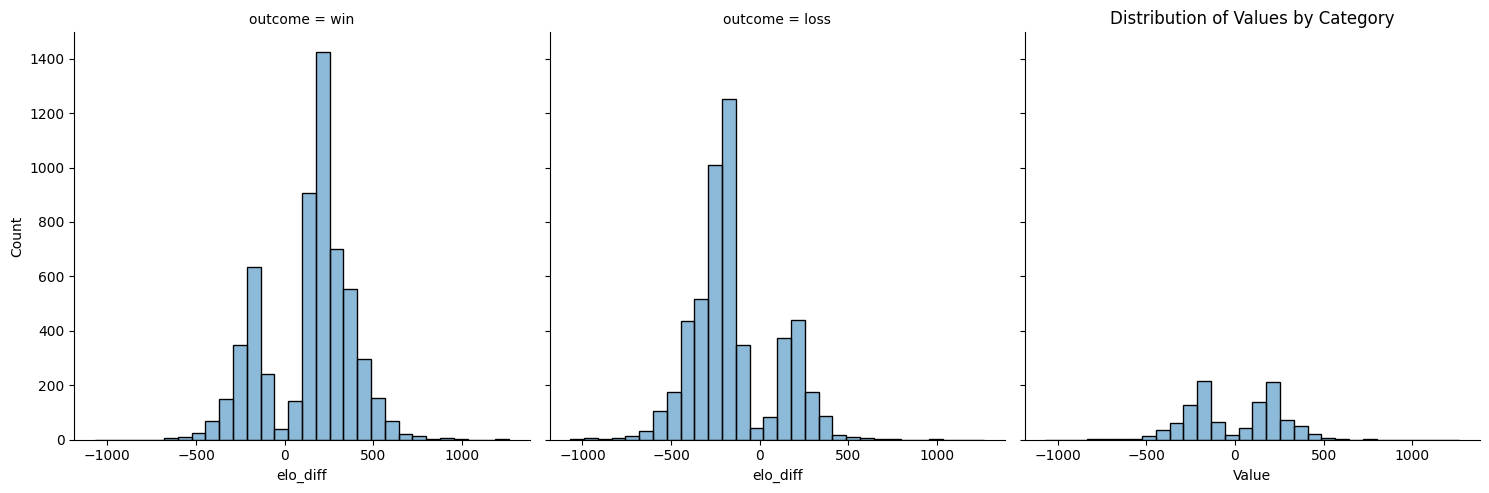

In [9]:
plt.figure(figsize=(8, 5))
sns.displot(
    data=df,
    x='elo_diff',
    col='outcome',
    kde=False,
    bins=30,
    alpha=0.5
)

plt.title('Distribution of Values by Category')
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [11]:
train_mask = ~df["tournament"].str.contains("titled-tuesday-blitz-april-14-2026-6362193")
test_mask = df["tournament"].str.contains("titled-tuesday-blitz-april-14-2026-6362193")

X = df[['white_elo', 'black_elo', 'elo_diff',
         'white_title_ordinal', 'black_title_ordinal']]
y = df[['outcome']]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, y_train = X[train_mask], y_encoded[train_mask]
X_test, y_test = X[test_mask], y_encoded[test_mask]


/home/lornarbreton/.local/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


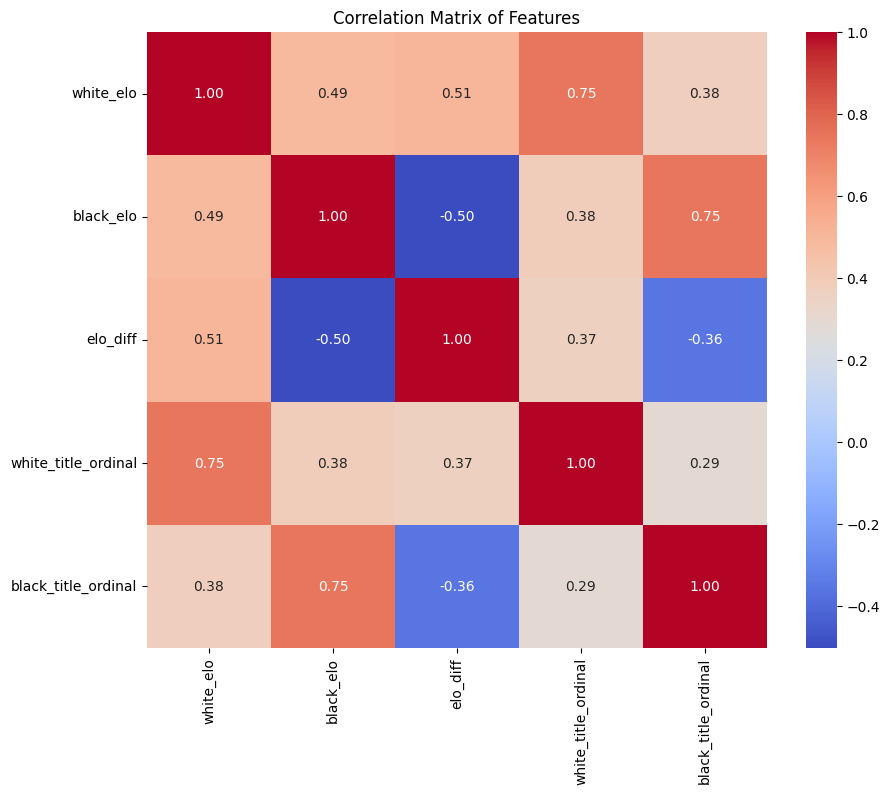

In [12]:
corr_matrix = X_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [13]:
import xgboost as xgb

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
#)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [14]:
params = {
    "objective": "multi:softprob",   # use multi:softmax if you just want class labels
    "num_class": num_classes,
    "eval_metric": "mlogloss",       # or 'merror'
    "max_depth": 10,
    "eta": 0.1,                      # learning rate
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "seed": 42,
}


In [15]:
evals = [(dtrain, "train"), (dtest, "eval")]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50,
)

[0]	train-mlogloss:0.89733	eval-mlogloss:0.91533
[50]	train-mlogloss:0.54385	eval-mlogloss:0.85770
[64]	train-mlogloss:0.51284	eval-mlogloss:0.86748


In [16]:
y_pred_probs = model.predict(dtest)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6570644718792867

Classification Report:
              precision    recall  f1-score   support

        draw       0.22      0.01      0.03       138
        loss       0.63      0.72      0.67       602
         win       0.68      0.73      0.71       718

    accuracy                           0.66      1458
   macro avg       0.51      0.49      0.47      1458
weighted avg       0.62      0.66      0.63      1458


Confusion Matrix:
[[  2  60  76]
 [  2 432 168]
 [  5 189 524]]


In [17]:
from sklearn.metrics import roc_auc_score, log_loss

# Ranked Probability Score (lower = better)
def rps(proba, y_true, n_classes=None):
    if n_classes is None:
        n_classes = proba.shape[1]
    one_hot = np.zeros_like(proba)
    one_hot[np.arange(len(y_true)), y_true] = 1
    cum_pred = np.cumsum(proba[:, :-1], axis=1)
    cum_true = np.cumsum(one_hot[:, :-1], axis=1)
    return ((cum_pred - cum_true) ** 2).sum(axis=1) / (n_classes - 1)

def multiclass_log_loss(proba, y_true):
    return log_loss(y_true, proba, normalize=False) * np.ones(len(y_true))

# Derive draw class index from the fitted LabelEncoder
draw_class_idx = list(le.classes_).index('draw')

y_pred_proba = model.predict(dtest)  # [n x 3], columns ordered to match class encoding
is_draw_true = (y_test == draw_class_idx).astype(int)
p_draw = y_pred_proba[:, draw_class_idx]
print(f"XGBoost AUC for P(draw): {roc_auc_score(is_draw_true, p_draw):.3f}")

# RPS/log loss on this split, for direct comparison to the Dirichlet-Multinomial numbers
print(f"RPS:      {rps(y_pred_proba, y_test).mean():.4f}")
print(f"Log loss: {log_loss(y_test, y_pred_proba):.4f}")


XGBoost AUC for P(draw): 0.541
RPS:      0.1497
Log loss: 0.8675


In [18]:
import umap

reducer = umap.UMAP(n_neighbors=500, min_dist=0.1, n_components=2, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_umap = reducer.fit_transform(X_scaled)

KeyboardInterrupt: 

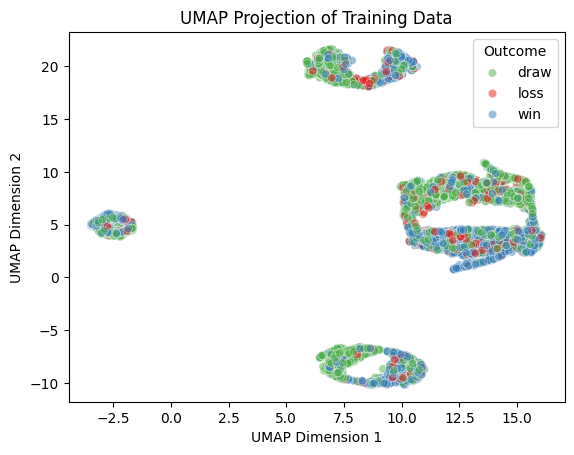

In [ ]:
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_train, palette='Set1', alpha=0.5)
plt.title('UMAP Projection of Training Data')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Outcome', labels=le.classes_)
plt.show()

In [ ]:
df[df['outcome'] == 'draw'].shape

(1080, 100)

In [19]:
# Ordinal classification

class_mapping = {'win': 1, 'draw': 0, 'loss': -1}
y_ordinal = y['outcome'].map(class_mapping)

y_ordinal_train = y_ordinal[train_mask]
y_ordinal_test = y_ordinal[test_mask]

In [20]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)

X_train_const = sm.add_constant(X_train_scaled)
model_ordinal = sm.OLS(y_ordinal_train, X_train_const.astype(float)).fit()
print(model_ordinal.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     933.3
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        03:45:06   Log-Likelihood:                -12894.
No. Observations:               10573   AIC:                         2.580e+04
Df Residuals:                   10568   BIC:                         2.583e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0523    

In [22]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(25,50,25), max_iter=10_000, random_state=42)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

confusion_mtx = confusion_matrix(y_test, y_pred_mlp)
print("MLP Accuracy:", mlp_accuracy)
print("MLP Confusion Matrix:\n", confusion_mtx)

MLP Accuracy: 0.39711934156378603
MLP Confusion Matrix:
 [[ 53  77   8]
 [150 443   9]
 [315 320  83]]
